<a href="https://colab.research.google.com/github/AlissonValencia/IA_practicas/blob/main/ia_practica4_Valencia_Larrea.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

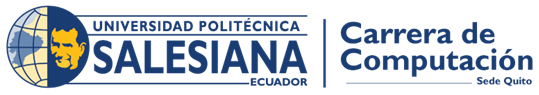

## **Perceptrón Multicapa (MLP) y Backpropagation**

Nombre: Alisson Valencia

Materia: Inteligencia Artificial

Práctica: 4

---

#***ACTIVIDADES A DESARROLLAR:***

El perceptrón multicapa permite superar las limitaciones del perceptrón simple, especialmente en problemas no linealmente separables como XOR. Para ello, incorpora capas ocultas y funciones de activación no lineales que transforman internamente los datos antes de generar una salida.

El aprendizaje de una red MLP se realiza ajustando sus pesos y sesgos con base en el error cometido. Este proceso se lleva a cabo mediante backpropagation, algoritmo que calcula la contribución de cada parámetro al error final utilizando la regla de la cadena y el descenso de gradiente.

En esta práctica se analizará una sola iteración de aprendizaje en una red 2-2-1 aplicada a XOR. Primero se resolverá el procedimiento de forma manual y luego se implementará en Python para validar los resultados. La actividad se centra en comprender el mecanismo interno del aprendizaje, no en utilizar librerías de alto nivel ni en entrenar completamente una red neuronal.

En esta práctica se analizará una red neuronal multicapa aplicada a un caso del problema XOR. La función XOR produce una salida positiva cuando las entradas son diferentes y una salida negativa cuando las entradas son iguales.

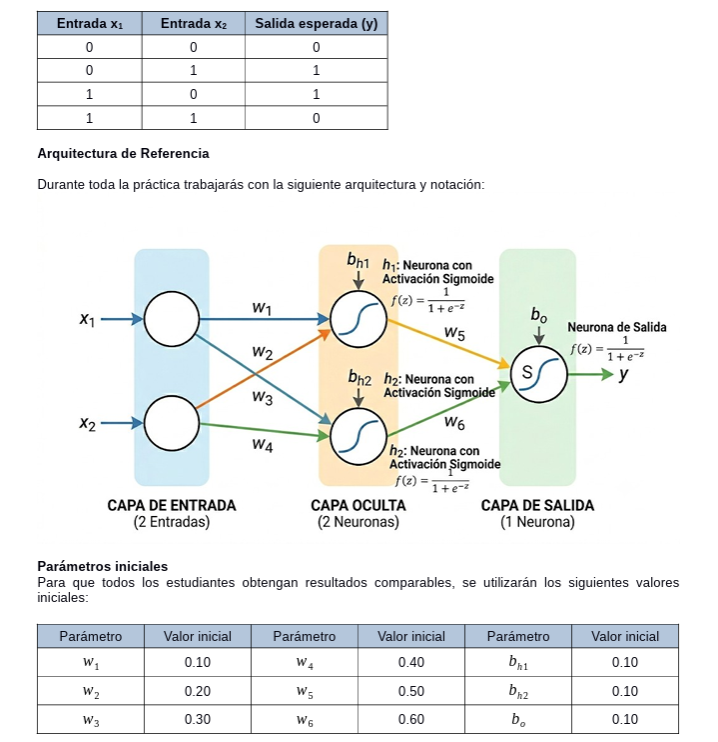

**Tasa de aprendizaje**

para la tasa de aprendizaje se establece el valor de η = 0.5

**Función de activación**

En todas las neuronas se utilizará la función sigmoide:

      σ(z)= 1/1+e^−z

Su derivada se calculará usando la salida ya activada:

                σ′(z)=a(1−a)
      Donde:
                    a=σ(z)
      
Esta forma es conveniente porque, una vez calculada la salida de una neurona, su derivada puede obtenerse directamente sin volver a calcular la exponencial.

**Función de pérdida o Error**

Se utilizará la función de error cuadrático para un solo ejemplo:
      
      E=1/2 (y − ŷ)^2
      Donde:
        ● y es la salida esperada.
        ● ŷ es la salida producida por la red.
        ● E representa el error de predicción.
El factor ½ se utiliza para simplificar la derivada durante el proceso de retropropagación.




#***Fase 1: Resolución manual***

En esta fase se realizará manualmente, utilizando una calculadora u hoja de cálculo, para una iteración completa del algoritmo de backpropagation en una red neuronal MLP con arquitectura 2-2-1. El objetivo es comprender cómo se obtiene la salida de la red y cómo se calcula el error. Luego, este error se propaga hacia atrás para determinar la responsabilidad de cada peso en dicho error. La retropropagación permite calcular los gradientes necesarios para actualizar los parámetros de la red.

In [4]:
import math
import random
import matplotlib.pyplot as plt

eta = 0.5

def sigmoid(z):
    return 1/(1+math.exp(-z))

def compute_error(y, y_pred):
    return 0.5*(y-y_pred)**2

def initialize_weights(use_fixed=True):

    if use_fixed:

        return {
            "w1":0.10,
            "w2":0.20,
            "w3":0.30,
            "w4":0.40,
            "w5":0.50,
            "w6":0.60,
            "bh1":0.10,
            "bh2":0.10,
            "bo":0.10
        }

    else:

        return {
            "w1":random.uniform(-1,1),
            "w2":random.uniform(-1,1),
            "w3":random.uniform(-1,1),
            "w4":random.uniform(-1,1),
            "w5":random.uniform(-1,1),
            "w6":random.uniform(-1,1),
            "bh1":random.uniform(-1,1),
            "bh2":random.uniform(-1,1),
            "bo":random.uniform(-1,1)
        }

def forward_pass(x1,x2,p):

    zh1=x1*p["w1"]+x2*p["w2"]+p["bh1"]
    ah1=sigmoid(zh1)

    zh2=x1*p["w3"]+x2*p["w4"]+p["bh2"]
    ah2=sigmoid(zh2)

    zo=ah1*p["w5"]+ah2*p["w6"]+p["bo"]

    y_pred=sigmoid(zo)

    return zh1,ah1,zh2,ah2,zo,y_pred

def backward_pass(x1,x2,y,ah1,ah2,y_pred,p):

    delta_o=(y_pred-y)*y_pred*(1-y_pred)

    delta_h1=delta_o*p["w5"]*ah1*(1-ah1)

    delta_h2=delta_o*p["w6"]*ah2*(1-ah2)

    return delta_o,delta_h1,delta_h2

def update_weights(x1,x2,ah1,ah2,delta_o,delta_h1,delta_h2,p,eta):
    gradients={
        "w1":delta_h1*x1,
        "w2":delta_h1*x2,
        "w3":delta_h2*x1,
        "w4":delta_h2*x2,
        "w5":delta_o*ah1,
        "w6":delta_o*ah2,
        "bh1":delta_h1,
        "bh2":delta_h2,
        "bo":delta_o
    }
    for key in gradients:
        p[key]=p[key]-eta*gradients[key]
    return p,gradients

**Actividad 1.a – Propagación hacia adelante**

Utiliza el siguiente registro del problema XOR x1 = 1; x2=0; y = 1. La propagación hacia adelante consiste en calcular la salida de cada neurona desde la capa de entrada hasta la capa de salida. En esta red se deben calcular primero las salidas de las neuronas ocultas h1 y h2, y luego la salida final ŷ.

Calcula los valores de las neuronas ocultas

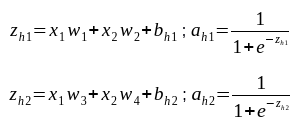

Calcula los valores de la neurona de salida

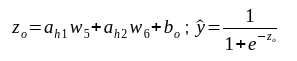



In [5]:
p = initialize_weights(use_fixed=True)

x1 = 1
x2 = 0
y = 1

zh1, ah1, zh2, ah2, zo, y_pred = forward_pass(x1, x2, p)
error_before = compute_error(y, y_pred)
delta_o, delta_h1, delta_h2 = backward_pass(
    x1,
    x2,
    y,
    ah1,
    ah2,
    y_pred,
    p
)
p_updated, gradients = update_weights(
    x1,
    x2,
    ah1,
    ah2,
    delta_o,
    delta_h1,
    delta_h2,
    p.copy(),
    eta
)
zh1_new, ah1_new, zh2_new, ah2_new, zo_new, y_pred_new = forward_pass(
    x1,
    x2,
    p_updated
)
error_after = compute_error(
    y,
    y_pred_new
)
print("ah1 =", round(ah1,4))
print("ah2 =", round(ah2,4))
print("ŷ =", round(y_pred,4))

print("Error =", round(error_before,4))
print()
print("delta_o =", round(delta_o,4))

print("delta_h1 =", round(delta_h1,4))
print("delta_h2 =", round(delta_h2,4))

print()
print("ŷ nuevo =", round(y_pred_new,4))
print("Error nuevo =", round(error_after,4))

ah1 = 0.5498
ah2 = 0.5987
ŷ = 0.6757
Error = 0.0526

delta_o = -0.0711
delta_h1 = -0.0088
delta_h2 = -0.0102

ŷ nuevo = 0.6891
Error nuevo = 0.0483


*   **Pregunta guía: ¿Cuáles son los valores de ah1, ah2 y ŷ?**

        Los valores obtenidos son:
            - ah1 = 0.5498
            - ah2 = 0.5987
            - ŷ = 0.6757


**Actividad 1.b – Cálculo del error**


Una vez obtenida la salida de la red, calcula el error usando:
      
      E=1/2 (y − ŷ)^2

In [7]:
error_before = compute_error(y, y_pred)

print("Actividad 1.b - Cálculo del error")
print("E =", round(error_before, 4))

Actividad 1.b - Cálculo del error
E = 0.0526


*   **Pregunta guía: ¿La salida Justifica tu respuesta.**

        - La salida ŷ = 0.6757 está relativamente cerca de la salida esperada y = 1, pero todavía no es suficientemente cercana.
        - El error obtenido es E = 0.0526. No es un error demasiado alto, pero todavía puede reducirse mediante la actualización
          de pesos.


**Actividad 1.c – Retropropagación del error**

El delta de salida representa la sensibilidad del error respecto a la entrada neta de la neurona de salida. Para esta práctica, se calcula mediante:

      δo =(ŷ − y)ŷ(1 − ŷ)
      Donde:
        ● ŷ−y indica la diferencia entre la salida calculada y la salida esperada.
        ● ŷ(1−ŷ) corresponde a la derivada de la función sigmoide.
El error de una neurona oculta no se calcula directamente comparando su salida con y. Su error depende de cuánto contribuyó al error de la neurona de salida.
      
      δh1 =δo w5 ah1 (1−ah1 )
      δh2 =δo w6 ah2 (1−ah2 )

In [8]:
delta_o, delta_h1, delta_h2 = backward_pass(x1, x2, y, ah1, ah2, y_pred, p)

print("Actividad 1.c - Retropropagación")
print("δo  =", round(delta_o, 4))
print("δh1 =", round(delta_h1, 4))
print("δh2 =", round(delta_h2, 4))

Actividad 1.c - Retropropagación
δo  = -0.0711
δh1 = -0.0088
δh2 = -0.0102


*   **Pregunta guía: ¿Cuáles son los valores de δh1, δh2 y δo?**

        Los valores obtenidos son:
            - δo = -0.0711
            - δh1 = -0.0088
            - δh2 = -0.0102



**Actividad 1.d – Cálculo de los gradientes**

Los gradientes indican cuánto debe modificarse cada peso para reducir el error. Para los pesos que conectan la capa oculta con la salida:

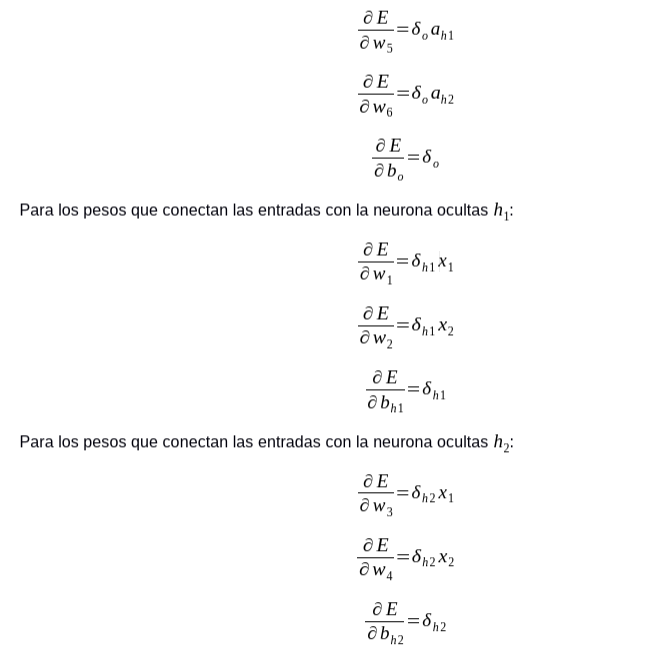

*   **Pregunta guía: ¿Por qué el error de las neuronas ocultas depende de los pesos w5 y w6? ¿Por qué los gradientes de w2 y w4 son cercanos a cero en esta iteración? ¿Qué representa un gradiente negativo?**

        - El error de las neuronas ocultas depende de w5 y w6 porque esos pesos conectan la capa oculta con la neurona de salida.
        - Los gradientes de w2 y w4 son cero porque en esta iteración x2 = 0. Al multiplicar el delta por x2, el resultado es cero.
        - Un gradiente negativo representa que, al aplicar la fórmula de actualización, el peso aumentará.



**Actividad 1.e - Actualización de pesos y bias**

En la actividad anterior se calcularon los gradientes de la red. En esta fase se utilizarán esos valores para actualizar los pesos y sesgos mediante la regla de descenso de gradiente. La actualización de parámetros permite que la red modifique su comportamiento para reducir el error en futuras iteraciones.

Para actualizar un peso se utiliza la siguiente expresión:

      wnuevo=wactual −η∂E / ∂w
Para actualizar un bias se utiliza:

      bnuevo=bactual −η∂E / ∂b
Recuerda que ara esta práctica se utiliza η=0.50.

*   **Pregunta guía: Complete el siguiente cuadro con los valores obtenidos para la actualización de los pesos y el bias de las neuronas de la red.**





In [12]:
print("-"*55)
print(f'{"Parámetro":<10} {"Inicial":<12} {"Gradiente":<12} {"Actualizado":<12}')

print("-"*55)
initial_values = initialize_weights(use_fixed=True)

for key in initial_values:
    print(
        f'{key:<10} '
        f'{initial_values[key]:<12.4f} '
        f'{gradients[key]:<12.4f} '
        f'{p_updated[key]:<12.4f}'
    )

-------------------------------------------------------
Parámetro  Inicial      Gradiente    Actualizado 
-------------------------------------------------------
w1         0.1000       -0.0088      0.1044      
w2         0.2000       -0.0000      0.2000      
w3         0.3000       -0.0102      0.3051      
w4         0.4000       -0.0000      0.4000      
w5         0.5000       -0.0391      0.5195      
w6         0.6000       -0.0425      0.6213      
bh1        0.1000       -0.0088      0.1044      
bh2        0.1000       -0.0102      0.1051      
bo         0.1000       -0.0711      0.1355      


*   **Preguntas guía:¿Qué pesos aumentaron después de la actualización? ¿Qué pesos permanecieron iguales? ¿Por qué w2) y w4 no cambiaron en esta iteración? ¿Qué efecto tiene un gradiente negativo en la actualización de un peso? ¿Qué relación existe entre la tasa de aprendizaje (\eta) y el tamaño del cambio aplicado a cada parámetro? ¿Qué podría ocurrir si la tasa de aprendizaje fuera demasiado grande? ¿Qué podría ocurrir si la tasa de aprendizaje fuera demasiado pequeña?**


        Los pesos y bias que aumentaron fueron:
            - w1
            - w3
            - w5
            - w6
            - bh1
            - bh2
            - bo

        Los pesos que permanecieron iguales fueron:
            - w2
            - w4
        - w2 y w4 no cambiaron porque dependen de x2, y en esta iteración x2 = 0.
        - Un gradiente negativo hace que el peso aumente, porque la fórmula es:
            peso nuevo = peso actual - η * gradiente
        - La tasa de aprendizaje η controla el tamaño del cambio aplicado a cada parámetro. Si η es muy grande, la red puede
          volverse inestable. Si η es muy pequeña, la red aprenderá muy lentamente.



**Actividad 1.f – Comprobación**

Después de actualizar los pesos y bias, es necesario comprobar cómo cambió la salida de la red. Para ello, se realizará una nueva propagación hacia adelante utilizando los parámetros actualizados. El objetivo de esta fase no es entrenar completamente la red, sino verificar si una sola actualización permitió acercar la salida estimada ^y a la salida esperada y. Realizar la propagación hacia adelante (actividad 1.a) y el cálculo del error (actividad 1.b) con los nuevos parámetros y complete la siguiente tabla:

In [30]:
print("-"*65)
print(f'{"Magnitud":<12} {"Antes de actualizar":<25} {"Después de actualizar":<12}')

print("-"*65)

print(
    f'{"ŷ":<12}'
    f'{y_pred:<28.4f}'
    f'{y_pred_new:<16.4f}'
)

print(
    f'{"E":<12}'
    f'{error_before:<28.4f}'
    f'{error_after:<16.4f}'
)

print("-"*65)

-----------------------------------------------------------------
Magnitud     Antes de actualizar       Después de actualizar
-----------------------------------------------------------------
ŷ           0.6757                      0.6891          
E           0.0526                      0.0483          
-----------------------------------------------------------------


*   **Pregunta guía:  ¿La nueva salida aumentó o disminuyó respecto a la anterior? ¿La nueva salida está más cerca de la salida esperada (y = 1)? ¿El nuevo error es menor que el error inicial?**

        - La nueva salida aumentó de 0.6757 a 0.6891.
        - La nueva salida está más cerca de la salida esperada y = 1.
        - El error disminuyó de 0.0526 a 0.0483, por lo tanto la actualización de pesos ayudó a mejorar el resultado.



#***Fase 2: Implementación en Python del algoritmo Backpropagation***

En esta fase se implementará en Python el algoritmo de backpropagation aplicado al problema XOR. El objetivo es que el estudiante programe manualmente el funcionamiento interno de una red neuronal multicapa, sin utilizar librerías especializadas de aprendizaje profundo.

La implementación debe permitir:

    ● Verificar una iteración del algoritmo usando los resultados obtenidos manualmente.

    ● Entrenar la red con todos los datos del problema XOR.

    ● Observar cómo disminuye el error durante el entrenamiento.

    ● Evaluar si la red aprende correctamente la función XOR.

    ● Imprimir resultados relevantes del proceso de aprendizaje.

**Actividad 2.1 – Dataset**

Define en una celda las listas X y Y con los 4 patrones del XOR mostrados en la fase anterios.

In [32]:
X = [[0, 0], [0, 1], [1, 0], [1, 1]]
Y = [0, 1, 1, 0]

print("-"*30)
print(f'{"x1":<8} {"x2":<8} {"y":<8}')
print("-"*30)

for i in range(len(X)):
    print(f'{X[i][0]:<8} {X[i][1]:<8} {Y[i]:<8}')

print("-"*30)

------------------------------
x1       x2       y       
------------------------------
0        0        0       
0        1        1       
1        0        1       
1        1        0       
------------------------------


**Actividad 2.b — Inicializar pesos y bias**

Crea una función initialize_weights() que inicialice los pesos y bias de las neuronas de la red neuronal.

In [33]:
p = initialize_weights(use_fixed=True)

print("-"*35)
print(f'{"Parámetro":<12} {"Valor inicial":<12}')
print("-"*35)

for key, value in p.items():
    print(f'{key:<12} {value:<12.4f}')

print("-"*35)

-----------------------------------
Parámetro    Valor inicial
-----------------------------------
w1           0.1000      
w2           0.2000      
w3           0.3000      
w4           0.4000      
w5           0.5000      
w6           0.6000      
bh1          0.1000      
bh2          0.1000      
bo           0.1000      
-----------------------------------


**Actividad 2.c — Propagación hacia adelante**

Crea la función sigmoid(z) usando math.exp, según la fórmula σ(z)= 1/(1+e−z).

Crea la función forward_pass() que calcule y retorne a_h0, a_h1, y_pred, siguiendo exactamente las fórmulas de la fase 1. Escribe el cálculo de cada neurona de forma explícita (sin bucles que oculten las fórmulas), de modo que cada línea de tu código se pueda comparar directamente con una fórmula de la pizarra de la última clase.

In [35]:
x1 = 1
x2 = 0
y = 1

zh1, ah1, zh2, ah2, zo, y_pred = forward_pass(x1, x2, p)

print("-"*30)
print(f'{"Magnitud":<12} {"Valor":<12}')
print("-"*30)

print(f'{"zh1":<12} {zh1:<12.4f}')
print(f'{"ah1":<12} {ah1:<12.4f}')
print(f'{"zh2":<12} {zh2:<12.4f}')
print(f'{"ah2":<12} {ah2:<12.4f}')
print(f'{"zo":<12} {zo:<12.4f}')
print(f'{"ŷ":<12} {y_pred:<12.4f}')

print("-"*30)

------------------------------
Magnitud     Valor       
------------------------------
zh1          0.2000      
ah1          0.5498      
zh2          0.4000      
ah2          0.5987      
zo           0.7341      
ŷ            0.6757      
------------------------------


**Actividad 2.d - Función de error y retropropagación**

Crea compute_error(y, y_pred) que retorne 1/2 ( y−ypred )2.

Crea la función backward_pass() que calcule y retorne δo, δh0, δh1, aplicando exactamente las fórmulas de la fase anterior.

In [36]:
error_before = compute_error(y, y_pred)

delta_o, delta_h1, delta_h2 = backward_pass(
    x1, x2, y, ah1, ah2, y_pred, p
)

print("-"*45)
print(f'{"Magnitud":<15} {"Valor":<12}')
print("-"*45)

print(f'{"Error E":<15} {error_before:<12.4f}')
print(f'{"delta_o":<15} {delta_o:<12.4f}')
print(f'{"delta_h1":<15} {delta_h1:<12.4f}')
print(f'{"delta_h2":<15} {delta_h2:<12.4f}')

print("-"*45)

---------------------------------------------
Magnitud        Valor       
---------------------------------------------
Error E         0.0526      
delta_o         -0.0711     
delta_h1        -0.0088     
delta_h2        -0.0102     
---------------------------------------------


**Actividad 2.d - Función de actualización**

Crea la función update_weights() que calcule cada gradiente y actualice cada peso y bias de la red, Recuerda que el valor de η=0.5.

**Actividad 2.e — Verificación manual**

Con los pesos que calcularon manualmente (y con el conjunto de pesos fijos que se definieron al inicio de la práctica), y el patrón x1 = 1; x2=0 ejecuta:
1. forward_pass y compute_error;
2. backward_pass;
3. update_weights;
4. forward_pass y compute_error

Verifica que el error haya disminuido. Ambos valores deben coincidir hasta al menos el cuarto decimal.

In [38]:
p_updated, gradients = update_weights(
    x1, x2, ah1, ah2,
    delta_o, delta_h1, delta_h2,
    p.copy(), eta
)

zh1_new, ah1_new, zh2_new, ah2_new, zo_new, y_pred_new = forward_pass(
    x1, x2, p_updated
)

error_after = compute_error(y, y_pred_new)

manual_values = {
    "w1": 0.1044,
    "w2": 0.2000,
    "w3": 0.3051,
    "w4": 0.4000,
    "w5": 0.5195,
    "w6": 0.6213,
    "bh1": 0.1044,
    "bh2": 0.1051,
    "bo": 0.1355
}

initial_values = initialize_weights(use_fixed=True)

print("-"*70)
print(f'{"Parámetro":<12} {"Inicial":<12} {"Manual":<12} {"Python":<12}')
print("-"*70)

for key in initial_values:
    print(
        f'{key:<12}'
        f'{initial_values[key]:<12.4f}'
        f'{manual_values[key]:<12.4f}'
        f'{p_updated[key]:<12.4f}'
    )

print("-"*70)

print("\nComparación de salida y error")
print("-"*55)
print(f'{"Magnitud":<12} {"Antes":<12} {"Después":<12}')
print("-"*55)
print(f'{"ŷ":<12}{y_pred:<12.4f}{y_pred_new:<12.4f}')
print(f'{"E":<12}{error_before:<12.4f}{error_after:<12.4f}')
print("-"*55)

----------------------------------------------------------------------
Parámetro    Inicial      Manual       Python      
----------------------------------------------------------------------
w1          0.1000      0.1044      0.1044      
w2          0.2000      0.2000      0.2000      
w3          0.3000      0.3051      0.3051      
w4          0.4000      0.4000      0.4000      
w5          0.5000      0.5195      0.5195      
w6          0.6000      0.6213      0.6213      
bh1         0.1000      0.1044      0.1044      
bh2         0.1000      0.1051      0.1051      
bo          0.1000      0.1355      0.1355      
----------------------------------------------------------------------

Comparación de salida y error
-------------------------------------------------------
Magnitud     Antes        Después     
-------------------------------------------------------
ŷ           0.6757      0.6891      
E           0.0526      0.0483      
--------------------------------------

*   **Pregunta guía: Complete el siguiente cuadro con los valores obtenidos para la actualización de los pesos y el bias de las neuronas de la red.**




In [39]:
print("Verificación manual vs Python")

print("-"*80)

print(
    f'{"Parámetro":<12}'
    f'{"Valor inicial":<18}'
    f'{"Manual":<22}'
    f'{"Python":<18}'
)

print("-"*80)

initial_values = initialize_weights(use_fixed=True)

manual_values = {
    "w1":0.1044,
    "w2":0.2000,
    "w3":0.3051,
    "w4":0.4000,
    "w5":0.5195,
    "w6":0.6213,
    "bh1":0.1044,
    "bh2":0.1051,
    "bo":0.1355
}

for key in manual_values:

    print(
        f'{key:<12}'
        f'{initial_values[key]:<18.4f}'
        f'{manual_values[key]:<22.4f}'
        f'{p_updated[key]:<18.4f}'
    )

print("-"*80)

print(
    f'{"ŷ":<12}'
    f'{y_pred:<18.4f}'
    f'{0.6891:<22.4f}'
    f'{y_pred_new:<18.4f}'
)

print(
    f'{"E":<12}'
    f'{error_before:<18.4f}'
    f'{0.0483:<22.4f}'
    f'{error_after:<18.4f}'
)

print("-"*80)

Verificación manual vs Python
--------------------------------------------------------------------------------
Parámetro   Valor inicial     Manual                Python            
--------------------------------------------------------------------------------
w1          0.1000            0.1044                0.1044            
w2          0.2000            0.2000                0.2000            
w3          0.3000            0.3051                0.3051            
w4          0.4000            0.4000                0.4000            
w5          0.5000            0.5195                0.5195            
w6          0.6000            0.6213                0.6213            
bh1         0.1000            0.1044                0.1044            
bh2         0.1000            0.1051                0.1051            
bo          0.1000            0.1355                0.1355            
--------------------------------------------------------------------------------
ŷ           0.675

#***Fase 3: Entrenamiento completo y evaluación***

El entrenamiento consiste en repetir, durante varias épocas, el ciclo forward → error → backward → update para cada uno de los 4 patrones del XOR.

**Actividad 3.a — Función de entrenamiento**

In [40]:
def train(X, Y, eta, epochs):
    p = initialize_weights(use_fixed=False)
    error_history = []

    for epoch in range(epochs):
        total_error = 0

        for i in range(len(X)):
            x1 = X[i][0]
            x2 = X[i][1]
            y = Y[i]

            zh1, ah1, zh2, ah2, zo, y_pred = forward_pass(x1, x2, p)

            error = compute_error(y, y_pred)

            delta_o, delta_h1, delta_h2 = backward_pass(
                x1, x2, y, ah1, ah2, y_pred, p
            )

            p, gradients = update_weights(
                x1, x2, ah1, ah2,
                delta_o, delta_h1, delta_h2,
                p, eta
            )

            total_error += error

        error_average = total_error / len(X)
        error_history.append(error_average)

    return p, error_history

print("La función train() fue creada correctamente.")

La función train() fue creada correctamente.


**Actividad 3.b — Entrenamiento y curva de error**

Entrenamiento finalizado.
Error inicial: 0.149181
Error final: 0.000147


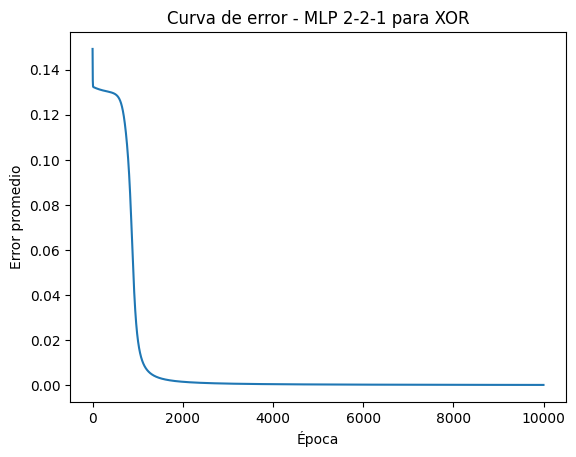

In [41]:
random.seed(1)

final_weights, error_history = train(
    X, Y,
    eta=0.5,
    epochs=10000
)

print("Entrenamiento finalizado.")
print("Error inicial:", round(error_history[0], 6))
print("Error final:", round(error_history[-1], 6))

plt.plot(error_history)
plt.xlabel("Época")
plt.ylabel("Error promedio")
plt.title("Curva de error - MLP 2-2-1 para XOR")
plt.show()

**Actividad 3.c — Evaluación del modelo entrenado**

Para cada uno de los 4 patrones del XOR, usa forward_pass con los pesos finales y construye una tabla como la siguiente:


In [50]:
print("-"*65)
print(f'{"x1":<8} {"x2":<8} {"y esperado":<15} {"ŷ":<12} {"Clase":<10}')
print("-"*65)

correctos = 0

for i in range(len(X)):
    x1 = X[i][0]
    x2 = X[i][1]
    y = Y[i]

    zh1, ah1, zh2, ah2, zo, y_pred = forward_pass(
        x1, x2, final_weights
    )

    clase = 1 if y_pred >= 0.5 else 0

    if clase == y:
        correctos += 1

    print(
        f'{x1:<8}'
        f'{x2:<8}'
        f'{y:<15}'
        f'{y_pred:<12.4f}'
        f'{clase:<10}'
    )

print("-"*65)
print("Aciertos:", correctos, "de", len(X))

-----------------------------------------------------------------
x1       x2       y esperado      ŷ            Clase     
-----------------------------------------------------------------
0       0       0              0.0189      0         
0       1       1              0.9838      1         
1       0       1              0.9837      1         
1       1       0              0.0169      0         
-----------------------------------------------------------------
Aciertos: 4 de 4


*  **Pregunta guía: ¿La red logró converger? ¿Qué tan cerca están las salidas ŷ de los valores 0 y 1 exactos? ¿Por qué una red entrenada con backpropagation y activación sigmoide nunca produce salidas exactamente 0 o 1?**

        - La red logró converger porque clasificó correctamente los cuatro patrones del XOR. Las salidas se acercan a 0 o 1,
          pero no llegan exactamente a esos valores.
        - Esto ocurre porque la función sigmoide nunca produce exactamente 0 o 1; solo se aproxima a esos valores.

#***Fase 4. Experimento: número de neuronas ocultas***

La arquitectura usada hasta ahora tiene 2 neuronas ocultas. En esta fase generalizarás tu implementación para que el número de neuronas ocultas sea un parámetro n_hidden, en lugar de un valor fijo de 2.

**Actividad 4.a — Generalización del código**

Modifica initialize_weights, forward_pass, backward_pass y update_weights para que reciban n_hidden como parámetro y trabajen con listas de tamaño n_hidden (en lugar de asumir 2 neuronas ocultas escritas explícitamente). Usa bucles para generalizar los cálculos.

In [51]:
def initialize_general_weights(n_hidden):
    p = {
        "hidden": [],
        "output": [],
        "bo": random.uniform(-1, 1)
    }

    for i in range(n_hidden):
        neuron = {
            "w1": random.uniform(-1, 1),
            "w2": random.uniform(-1, 1),
            "b": random.uniform(-1, 1)
        }

        p["hidden"].append(neuron)
        p["output"].append(random.uniform(-1, 1))

    return p


def forward_general(x1, x2, p):
    hidden_outputs = []

    for neuron in p["hidden"]:
        z = x1 * neuron["w1"] + x2 * neuron["w2"] + neuron["b"]
        a = sigmoid(z)
        hidden_outputs.append(a)

    zo = p["bo"]

    for i in range(len(hidden_outputs)):
        zo = zo + hidden_outputs[i] * p["output"][i]

    y_pred = sigmoid(zo)

    return hidden_outputs, y_pred


def backward_general(x1, x2, y, hidden_outputs, y_pred, p):
    delta_o = (y_pred - y) * y_pred * (1 - y_pred)
    delta_hidden = []

    for i in range(len(hidden_outputs)):
        ah = hidden_outputs[i]
        delta_h = delta_o * p["output"][i] * ah * (1 - ah)
        delta_hidden.append(delta_h)

    return delta_o, delta_hidden


def update_general(x1, x2, hidden_outputs, delta_o, delta_hidden, p, eta):
    for i in range(len(p["hidden"])):
        p["hidden"][i]["w1"] = p["hidden"][i]["w1"] - eta * delta_hidden[i] * x1
        p["hidden"][i]["w2"] = p["hidden"][i]["w2"] - eta * delta_hidden[i] * x2
        p["hidden"][i]["b"] = p["hidden"][i]["b"] - eta * delta_hidden[i]

        p["output"][i] = p["output"][i] - eta * delta_o * hidden_outputs[i]

    p["bo"] = p["bo"] - eta * delta_o

    return p


def train_general(X, Y, eta, epochs, n_hidden):
    p = initialize_general_weights(n_hidden)
    error_history = []

    for epoch in range(epochs):
        total_error = 0

        for i in range(len(X)):
            x1 = X[i][0]
            x2 = X[i][1]
            y = Y[i]

            hidden_outputs, y_pred = forward_general(x1, x2, p)

            error = compute_error(y, y_pred)

            delta_o, delta_hidden = backward_general(
                x1, x2, y, hidden_outputs, y_pred, p
            )
            p = update_general(
                x1, x2, hidden_outputs,
                delta_o, delta_hidden,
                p, eta
            )
            total_error += error

        error_history.append(total_error / len(X))
    return p, error_history
print("Código generalizado creado correctamente.")

Código generalizado creado correctamente.


**Actividad 4.b — Comparación de arquitecturas**

Entrena tres redes con los mismos valores de η y epochs, variando n_hidden  {1, 2, 4}. Cea una función random.seed(...) con el mismo valor antes de cada entrenamiento, para que los tres experimentos partan de condiciones comparables. Grafica las tres curvas de error_history en un mismo gráfico, una por cada valor de n_hidden.

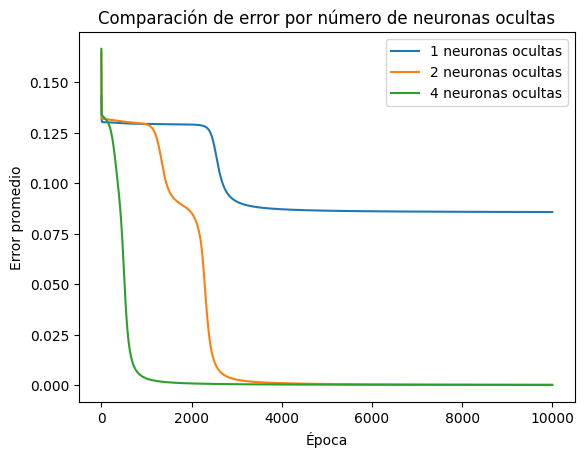

In [52]:
def evaluate_general(p):
    correct = 0
    results = []

    for i in range(len(X)):
        x1 = X[i][0]
        x2 = X[i][1]
        y = Y[i]

        hidden_outputs, y_pred = forward_general(x1, x2, p)

        clase = 1 if y_pred >= 0.5 else 0

        if clase == y:
            correct += 1

        results.append([x1, x2, y, y_pred, clase])

    learned = correct == len(X)

    return results, learned


architectures = [1, 2, 4]
comparison = []
models = {}
histories = {}

for n_hidden in architectures:
    random.seed(1)

    model, history = train_general(
        X, Y,
        eta=0.5,
        epochs=10000,
        n_hidden=n_hidden
    )

    models[n_hidden] = model
    histories[n_hidden] = history

    results, learned = evaluate_general(model)

    comparison.append([n_hidden, history[-1], learned])

    plt.plot(history, label=str(n_hidden) + " neuronas ocultas")

plt.xlabel("Época")
plt.ylabel("Error promedio")
plt.title("Comparación de error por número de neuronas ocultas")
plt.legend()
plt.show()

**Actividad 4.c — Tabla comparativa**

Completa la siguiente tabla comparativa.

In [53]:
print("-"*65)
print(f'{"Neuronas ocultas":<20} {"Error final":<15} {"¿Aprendió XOR?":<15}')
print("-"*65)

for row in comparison:
    n_hidden = row[0]
    error_final = row[1]
    learned = row[2]

    respuesta = "Sí" if learned else "No"

    print(
        f'{n_hidden:<20}'
        f'{error_final:<15.6f}'
        f'{respuesta:<15}'
    )

print("-"*65)

-----------------------------------------------------------------
Neuronas ocultas     Error final     ¿Aprendió XOR? 
-----------------------------------------------------------------
1                   0.085685       No             
2                   0.000180       Sí             
4                   0.000101       Sí             
-----------------------------------------------------------------


In [54]:
print("\nEvaluación detallada por arquitectura")

for n_hidden in architectures:
    print("\nArquitectura con", n_hidden, "neurona(s) oculta(s)")

    print("-"*65)
    print(f'{"x1":<8} {"x2":<8} {"Esperado":<12} {"ŷ":<12} {"Clase":<10}')
    print("-"*65)

    results, learned = evaluate_general(models[n_hidden])

    for row in results:
        print(
            f'{row[0]:<8}'
            f'{row[1]:<8}'
            f'{row[2]:<12}'
            f'{row[3]:<12.4f}'
            f'{row[4]:<10}'
        )

    print("-"*65)


Evaluación detallada por arquitectura

Arquitectura con 1 neurona(s) oculta(s)
-----------------------------------------------------------------
x1       x2       Esperado     ŷ            Clase     
-----------------------------------------------------------------
0       0       0           0.3301      0         
0       1       1           0.3282      0         
1       0       1           0.9770      1         
1       1       0           0.3291      0         
-----------------------------------------------------------------

Arquitectura con 2 neurona(s) oculta(s)
-----------------------------------------------------------------
x1       x2       Esperado     ŷ            Clase     
-----------------------------------------------------------------
0       0       0           0.0169      0         
0       1       1           0.9820      1         
1       0       1           0.9819      1         
1       1       0           0.0224      0         
-------------------------------

*   **Pregunta guía: ¿Qué ocurre con n_hidden = 1? Explica, en términos de las fórmulas de los deltas y de las salidas de la capa oculta, por qué una sola neurona oculta no es suficiente para que la red aprenda XOR. ¿Qué ventaja observas al aumentar a 4 neuronas ocultas? ¿Existe algún costo o desventaja al aumentar el número de neuronas ocultas?**

        - El notebook contiene una versión generalizada del algoritmo para trabajar con diferente número de neuronas ocultas.
          Se entrenaron redes con 1, 2 y 4 neuronas ocultas, se graficaron sus curvas de error y se construyó una tabla comparativa.
        - Se observó que una sola neurona oculta no es suficiente para aprender XOR, mientras que dos o más neuronas sí
          permiten resolver el problema.



**CONCLUSIONES:**

1. En esta práctica se implementó y analizó el funcionamiento de una red neuronal multicapa (MLP) utilizando el algoritmo de backpropagation para resolver el problema XOR. Primero, se realizó el procedimiento manual para comprender cómo se lleva a cabo la propagación hacia adelante, el cálculo del error, la retropropagación y la actualización de los pesos y sesgos mediante descenso de gradiente.

2. Posteriormente, se implementó el algoritmo en Python sin utilizar librerías de machine learning, lo que permitió comprender el funcionamiento interno de una red neuronal y verificar que los resultados obtenidos manualmente coinciden con los generados por el programa. Además, se observó que el error disminuye progresivamente durante el entrenamiento, demostrando la capacidad de aprendizaje de la red.

3. Finalmente, se comprobó que una red neuronal con una capa oculta es capaz de resolver problemas no linealmente separables como XOR y que el número de neuronas ocultas influye directamente en el desempeño del modelo. Esta práctica permitió fortalecer los conocimientos sobre redes neuronales, aprendizaje supervisado y la importancia del algoritmo de backpropagation en la inteligencia artificial.

In [55]:
!pip install nbconvert

!jupyter nbconvert --to html "/content/ia_practica4_Valencia_Larrea.ipynb"

[NbConvertApp] Converting notebook /content/ia_practica4_Valencia_Larrea.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 945245 bytes to /content/ia_practica4_Valencia_Larrea.html
